# Sentiment Analysis of Austen and Melville

DS 5001 Text as Data

**Purpose:** Use the NRC lexicon to explore sentiment in two novels.

# Set Up

## Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly_express as px
from IPython.display import display, HTML

In [2]:
sns.set()

## Config

In [3]:
import configparser
config = configparser.ConfigParser()
config.read("../../../env.ini")
data_home = config['DEFAULT']['data_home']
output_dir = config['DEFAULT']['output_dir']
local_lib = config['DEFAULT']['local_lib']

In [4]:
data_prefix = 'austen-melville'

In [5]:
novels_csv = f'{output_dir}/{data_prefix}-CORPUS.csv'
vocab_csv = f'{output_dir}/{data_prefix}-VOCAB2.csv'
lib_csv = f'{output_dir}/{data_prefix}-LIB_LABELS.csv'
bow_csv = f'{output_dir}/{data_prefix}-BOW-CHAPS.csv'

In [6]:
# For TOKENS
OHCO = ['book_id', 'chap_id', 'para_num', 'sent_num', 'token_num']
BOOKS = OHCO[:1]
CHAPS = OHCO[:2]
PARAS = OHCO[:3]
SENTS = OHCO[:4]

In [7]:
salex_csv = f'{data_home}/lexicons/salex_nrc.csv'
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

# Get Data

In [8]:
TOKENS = pd.read_csv(novels_csv).set_index(OHCO).sort_index()
VOCAB = pd.read_csv(vocab_csv).set_index('term_str').sort_index()
LIB = pd.read_csv(lib_csv).set_index('book_id')[['author','title']].sort_index()
BOW = pd.read_csv(bow_csv).set_index(['book_id','chap_id','term_str']).sort_index()

In [9]:
LIB['author_id'] = LIB.author.str.split(', ').str[0]
LIB['title_short'] = LIB.author_id + ' ' + LIB.index.astype('str') + ': ' + LIB.title.str[:25] 

In [10]:
LIB

,author,title,author_id,title_short
book_id,,,,
105,"AUSTEN, JANE",PERSUASION,AUSTEN,AUSTEN 105: PERSUASION
121,"AUSTEN, JANE",NORTHANGER ABBEY,AUSTEN,AUSTEN 121: NORTHANGER ABBEY
141,"AUSTEN, JANE",MANSFIELD PARK,AUSTEN,AUSTEN 141: MANSFIELD PARK
158,"AUSTEN, JANE",EMMA,AUSTEN,AUSTEN 158: EMMA
161,"AUSTEN, JANE",SENSE AND SENSIBILITY,AUSTEN,AUSTEN 161: SENSE AND SENSIBILITY
946,"AUSTEN, JANE",LADY SUSAN,AUSTEN,AUSTEN 946: LADY SUSAN
1212,"AUSTEN, JANE",LOVE AND FREINDSHIP SIC,AUSTEN,AUSTEN 1212: LOVE AND FREINDSHIP SIC
1342,"AUSTEN, JANE",PRIDE AND PREJUDICE,AUSTEN,AUSTEN 1342: PRIDE AND PREJUDICE
1900,"MELVILLE, HERMAN",TYPEE A ROMANCE OF THE SOUTH SEAS,MELVILLE,MELVILLE 1900: TYPEE A ROMANCE OF THE SO


In [11]:
persuasion = 105
mobydick = 2701

# Get SA Lexicon

In [12]:
SALEX = pd.read_csv(salex_csv).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]

In [13]:
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


# Compute Sentiment

## Join SALEX with VOCAB

In [14]:
V = VOCAB.join(SALEX, how='inner')

In [15]:
V.head()

,term_rank,n,n_chars,p,i,max_pos_group,max_pos,n_pos_group,cat_pos_group,n_pos,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
abandon,6946,20,7,0.000010,16.651555,VB,VB,3,"{'JJ', 'NN', 'VB'}",4,...,0,0,1,0,1,0,1,0,0,-1
abandoned,2555,72,9,0.000035,14.803558,VB,VBN,5,"{'VB', 'IN', 'JJ', 'RB', 'NN'}",6,...,0,0,1,0,1,0,1,0,0,-1
abandonment,8727,15,11,0.000007,17.066592,NN,NN,2,"{'JJ', 'NN'}",2,...,0,0,1,0,1,0,1,1,0,-1
aberration,19827,3,10,0.000001,19.388520,NN,NN,1,{'NN'},1,...,0,1,0,0,1,0,0,0,0,-1
abhor,10499,11,5,0.000005,17.514051,VB,VB,2,"{'NN', 'VB'}",3,...,0,1,1,0,1,0,0,0,0,-1


## Join VOCAB with BOW

In [16]:
B = BOW.join(V[['max_pos'] + emo_cols], on='term_str', rsuffix='_v', how='inner') #.dropna()

In [17]:
B

n        tf     tfidf max_pos  anger  \
book_id chap_id term_str                                           
105     1       admiration  1  0.000381  0.001182      NN      0   
                admire      1  0.000381  0.001539      VB      0   
                advise      1  0.000381  0.001876      VB      0   
                agreeable   2  0.000762  0.002047      JJ      0   
                alarm       1  0.000381  0.001282      NN      0   
...                        ..       ...       ...     ...    ...   
34970   114     warned      1  0.001550  0.008817     VBD      0   
                worse       1  0.001550  0.003924     JJR      0   
                wound       1  0.001550  0.005947      NN      1   
                wreck       1  0.001550  0.008079      NN      1   
                young       2  0.003101  0.003566      JJ      0   

                            anticipation  disgust  fear  joy  sadness  \
book_id chap_id term_str                                                
105     1       admiration             0        0     0    1        0   
                admire                 0        0     0    0        0   
                advise                 0        0     0    0        0   
                agreeable              0        0     0    0        0   
                alarm                  0        0     1    0        0   
...                                  ...      ...   ...  ...      ...   
34970   114     warned                 1        0     1    0        0   
                worse                  0        0     1    0        1   
                wound                  0        0     1    0        1   
                wreck                  0        1     1    0        1   
                young                  1        0     0    1        0   

                            surprise  trust  sentiment  
book_id chap_id term_str                                
105     1       admiration         0      1          1  
                admire             0      1          1  
                advise             0      1          1  
                agreeable          0      1          1  
                alarm              1      0         -1  
...                              ...    ...        ...  
34970   114     warned             1      0          0  
                worse              0      0         -1  
                wound              0      0         -1  
                wreck              1      0         -1  
                young              1      0          1  

[88593 rows x 13 columns]

## Weight Emotions by TFIDF

In [18]:
for col in emo_cols:
    B[col] = B[col] * B.tfidf

In [19]:
B.head()

n        tf     tfidf max_pos  anger  \
book_id chap_id term_str                                           
105     1       admiration  1  0.000381  0.001182      NN    0.0   
                admire      1  0.000381  0.001539      VB    0.0   
                advise      1  0.000381  0.001876      VB    0.0   
                agreeable   2  0.000762  0.002047      JJ    0.0   
                alarm       1  0.000381  0.001282      NN    0.0   

                            anticipation  disgust      fear       joy  \
book_id chap_id term_str                                                
105     1       admiration           0.0      0.0  0.000000  0.001182   
                admire               0.0      0.0  0.000000  0.000000   
                advise               0.0      0.0  0.000000  0.000000   
                agreeable            0.0      0.0  0.000000  0.000000   
                alarm                0.0      0.0  0.001282  0.000000   

                            sadness  surprise     trust  sentiment  
book_id chap_id term_str                                            
105     1       admiration      0.0  0.000000  0.001182   0.001182  
                admire          0.0  0.000000  0.001539   0.001539  
                advise          0.0  0.000000  0.001876   0.001876  
                agreeable       0.0  0.000000  0.002047   0.002047  
                alarm           0.0  0.001282  0.000000  -0.001282

# Explore Emotion Words and POS

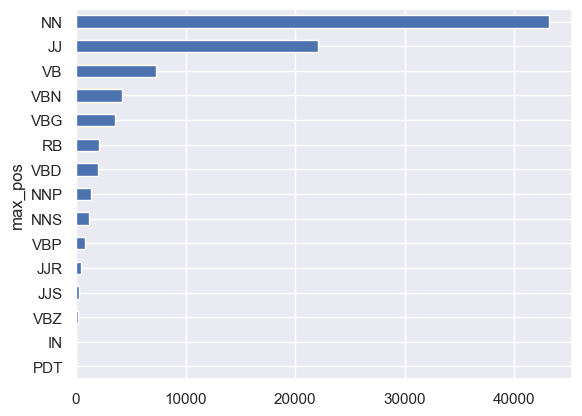

In [20]:
B.max_pos.value_counts().sort_values().plot.barh();

In [21]:
EMO_BOOKS = B.groupby(['book_id'])[emo_cols].mean()
EMO_CHAPS = B.groupby(['book_id','chap_id'])[emo_cols].mean()

In [22]:
EMO_BOOKS.index = LIB.title_short #book_title

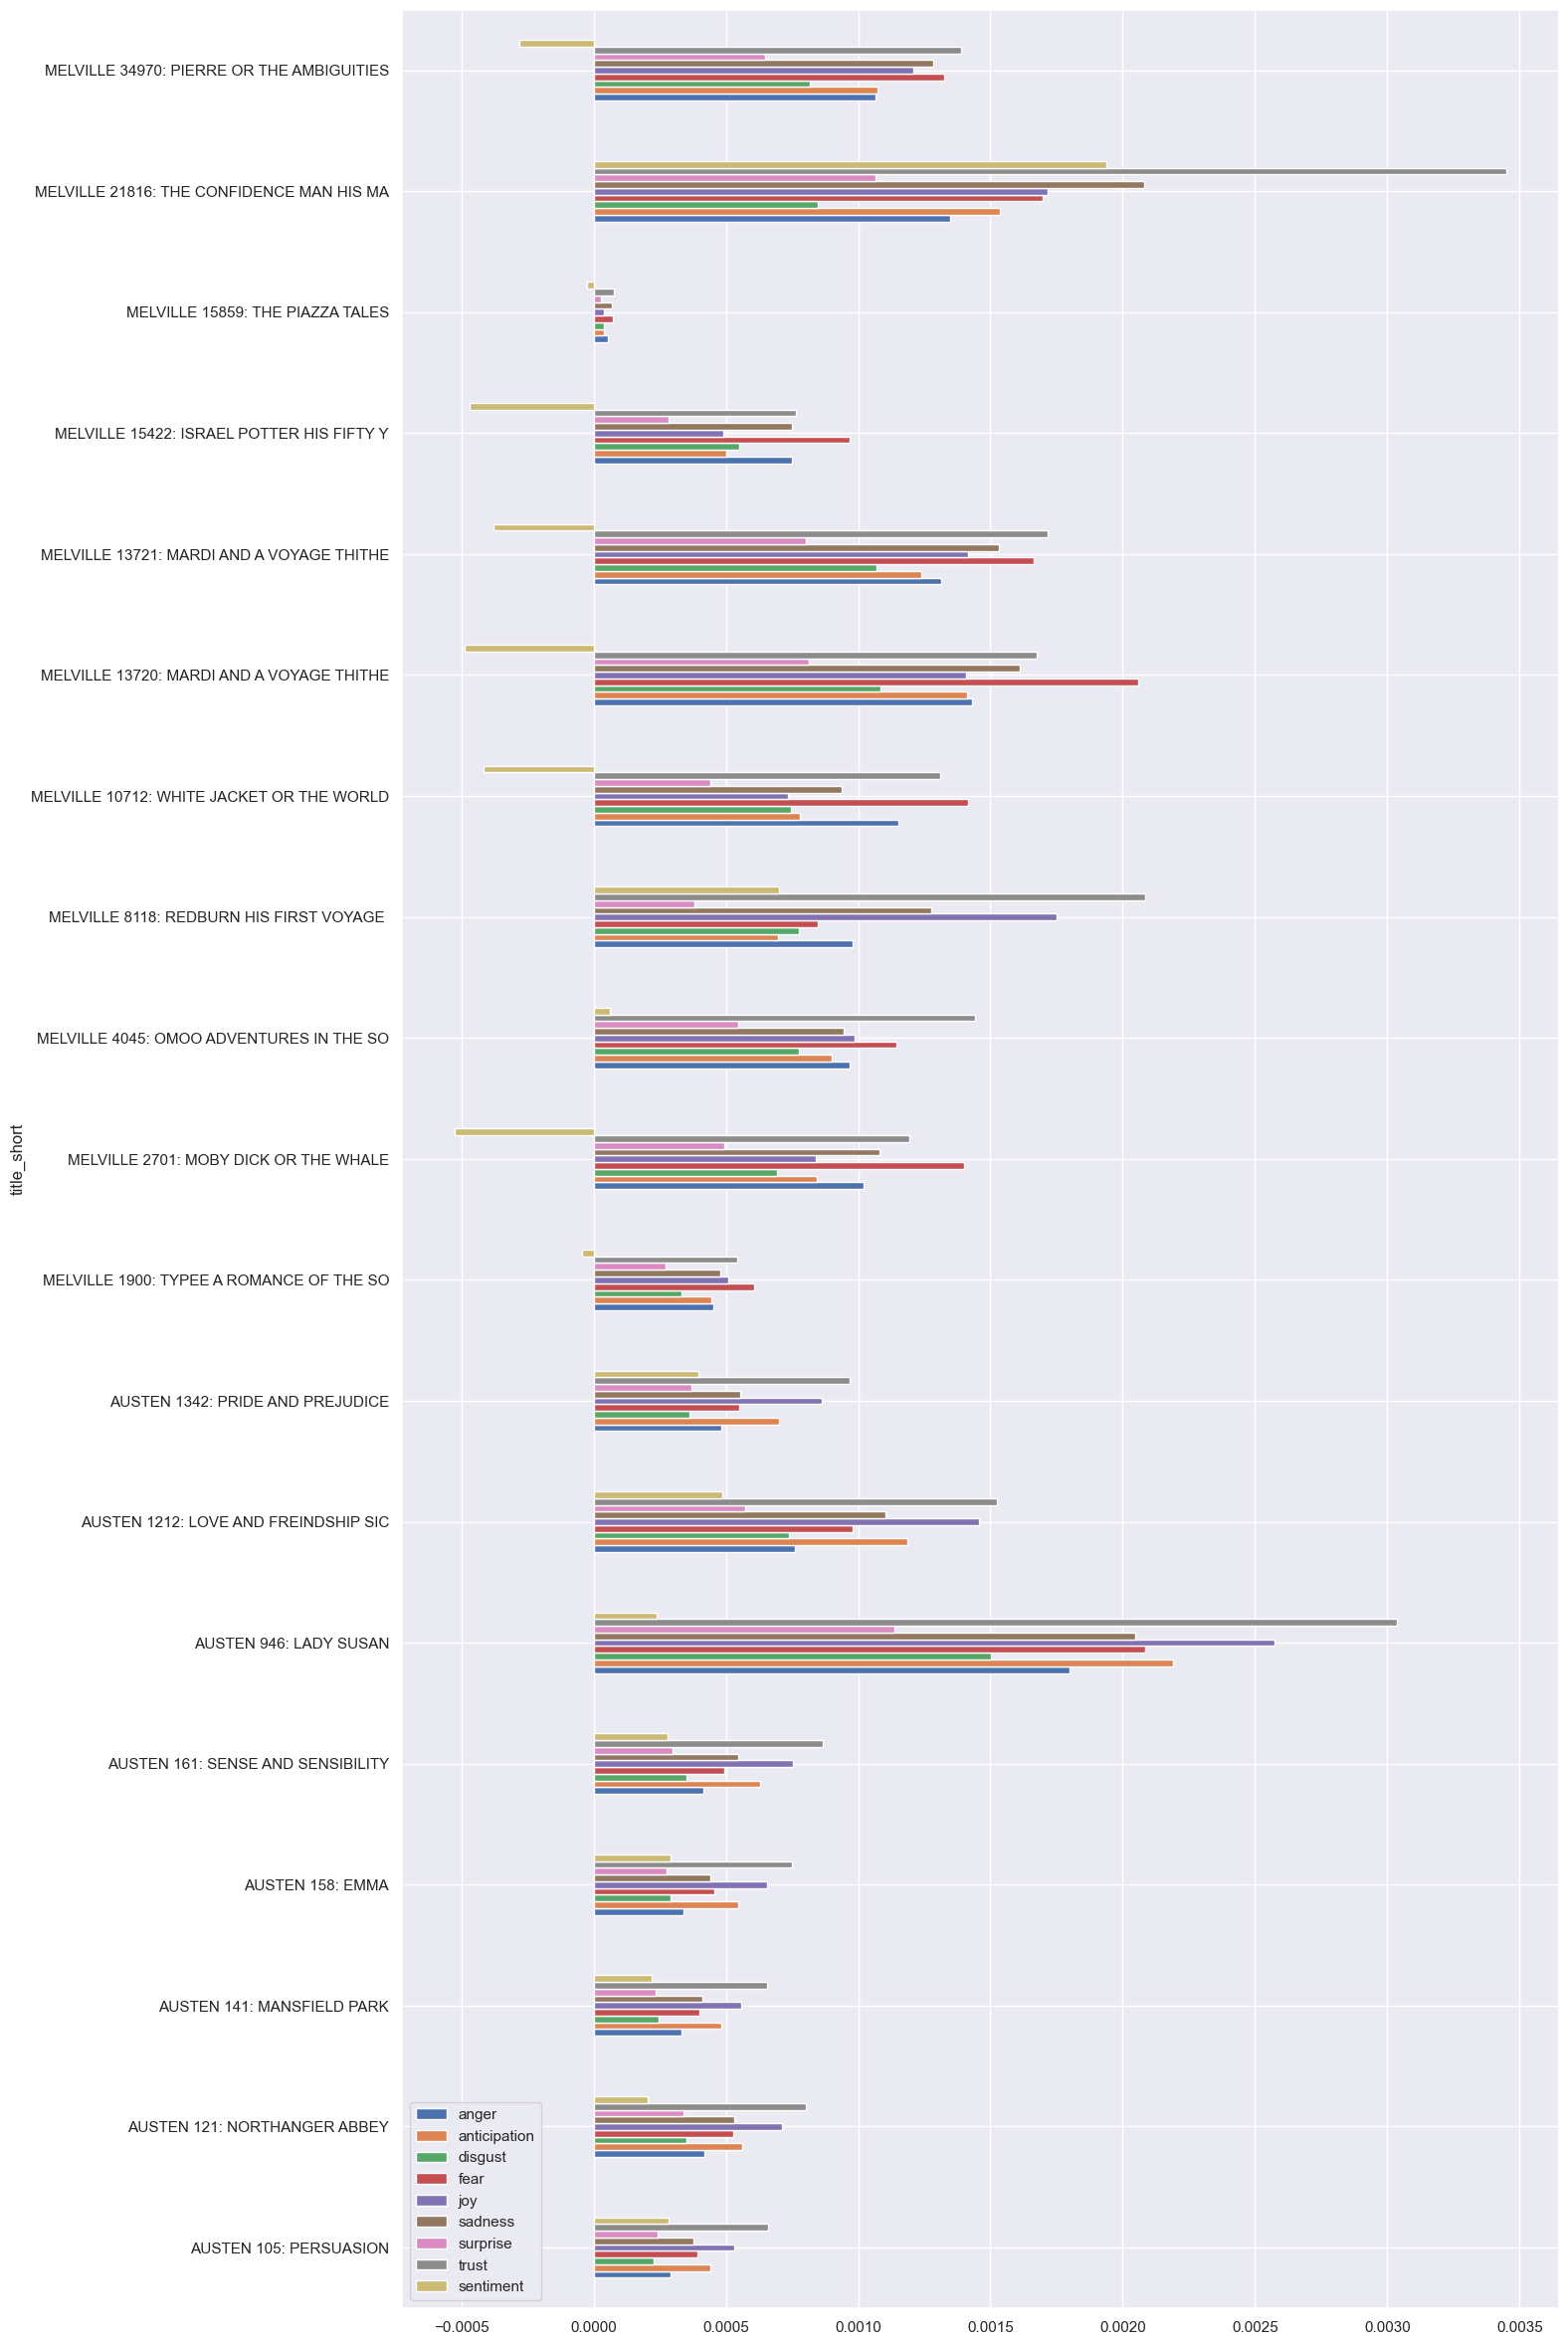

In [23]:
EMO_BOOKS.plot.barh(figsize=(15,30));

In [24]:
px.imshow(EMO_BOOKS.sort_values('sentiment'), 
          width=1200, height=1000, 
          color_continuous_midpoint=0, 
          color_continuous_scale=px.colors.diverging.Spectral)

# Compare Texts: Fear and Joy

In [25]:
PERSUASION = EMO_CHAPS.loc[persuasion].copy()
MOBYDICK = EMO_CHAPS.loc[mobydick].copy()

In [26]:
px.bar(PERSUASION.mean().sort_values(), orientation='h', width=500)

In [27]:
px.bar(MOBYDICK.mean().sort_values(), orientation='h', width=500)

In [28]:
# PERSUASION.mean().sort_values().plot.barh();
# MOBYDICK.mean().sort_values().plot.barh();

# What is Trust?

In [29]:
trust_words = pd.Series(SALEX[SALEX['trust'] == 1].index.tolist())

In [65]:
trust_words.sample(10)

712    reconsideration
603            officer
266         discretion
768              savor
760            saintly
553          matrimony
150           clerical
30              agreed
382               fuse
537             magnet
dtype: object

# Mean Sentiment by Chapter

In [31]:
PERSUASION_chaps = EMO_CHAPS.loc[persuasion] 
MOBYDICK_chaps = EMO_CHAPS.loc[mobydick] 

In [32]:
# PERSUASION_chaps.style.background_gradient(cmap='YlGnBu', axis=None)

In [33]:
px.imshow(PERSUASION.T, width=850, height=400, color_continuous_scale=px.colors.diverging.Spectral, color_continuous_midpoint=0.0)

In [34]:
px.bar(PERSUASION.sum(1).to_frame('sum_sent'), width=850)

In [35]:
# MOBYDICK_chaps.style.background_gradient(cmap='YlGnBu', axis=0)

In [36]:
px.imshow(MOBYDICK.T, width=1350, height=400, color_continuous_scale=px.colors.diverging.Spectral, text_auto=False, color_continuous_midpoint=0.0)

In [37]:
px.bar(MOBYDICK.sum(1).to_frame('sum_sent'), width=1350)

In [38]:
' '.join(TOKENS.loc[(mobydick, 125), 'token_str'].to_list())

'THE MAIN TOP SAIL YARD. TASHTEGO PASSING NEW LASHINGS AROUND IT. "Um, um, um. Stop that thunder! Plenty too much thunder up here. What\'s the use of thunder? Um, um, um. We don\'t want thunder; we want rum; give us a glass of rum. Um, um, um!"'

In [39]:
PERSUASION_chaps_thin = EMO_CHAPS.loc[persuasion].stack().to_frame('valence').reset_index().rename(columns={'level_1':'emo'})
MOBYDICK_chaps_thin = EMO_CHAPS.loc[mobydick].stack().to_frame('valence').reset_index().rename(columns={'level_1':'emo'})

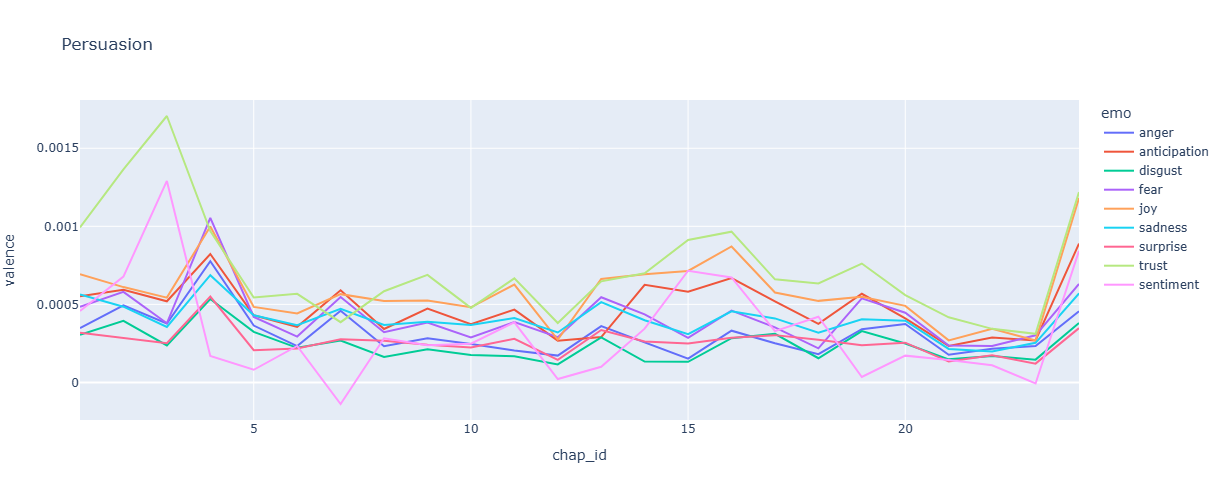

In [66]:
px.line(PERSUASION_chaps_thin, x='chap_id', y='valence', color='emo', height=500, title="Persuasion")

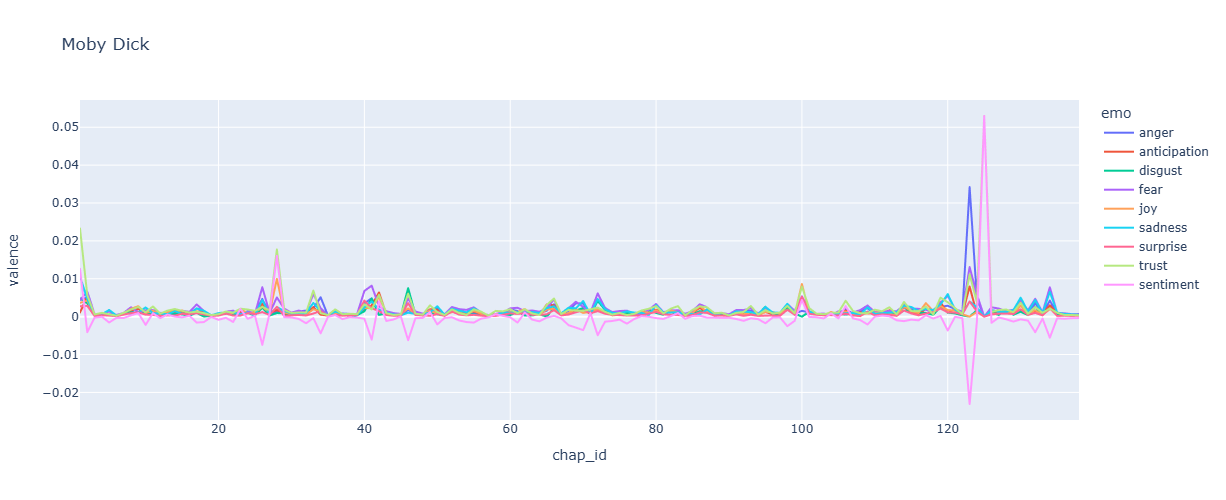

In [67]:
px.line(MOBYDICK_chaps_thin, x='chap_id', y='valence', color='emo', height=500, title="Moby Dick")

# Cose Read Sentiment in Texts

## Combine VOCAB + SALEX with TOKENS

We need to do this to reconstruct the sentences, which are lost in the BOW representation.

In [42]:
T = TOKENS.join(V, on='term_str').fillna(0)

In [43]:
T.head()

pos_tuple  pos  \
book_id chap_id para_num sent_num token_num                             
105     1       1        0        0               ('Sir', 'NNP')  NNP   
                                  1            ('Walter', 'NNP')  NNP   
                                  2           ('Elliot,', 'NNP')  NNP   
                                  3                 ('of', 'IN')   IN   
                                  4          ('Kellynch', 'NNP')  NNP   

                                            token_str  term_str pos_group  \
book_id chap_id para_num sent_num token_num                                 
105     1       1        0        0               Sir       sir        NN   
                                  1            Walter    walter        NN   
                                  2           Elliot,    elliot        NN   
                                  3                of        of        IN   
                                  4          Kellynch  kellynch        NN   

                                             term_rank       n  n_chars  \
book_id chap_id para_num sent_num token_num                               
105     1       1        0        0              135.0  1798.0      3.0   
                                  1                0.0     0.0      0.0   
                                  2                0.0     0.0      0.0   
                                  3                0.0     0.0      0.0   
                                  4                0.0     0.0      0.0   

                                                    p          i  ...  \
book_id chap_id para_num sent_num token_num                       ...   
105     1       1        0        0          0.000873  10.161306  ...   
                                  1          0.000000   0.000000  ...   
                                  2          0.000000   0.000000  ...   
                                  3          0.000000   0.000000  ...   
                                  4          0.000000   0.000000  ...   

                                            anticipation disgust  fear  joy  \
book_id chap_id para_num sent_num token_num                                   
105     1       1        0        0                  0.0     0.0   0.0  0.0   
                                  1                  0.0     0.0   0.0  0.0   
                                  2                  0.0     0.0   0.0  0.0   
                                  3                  0.0     0.0   0.0  0.0   
                                  4                  0.0     0.0   0.0  0.0   

                                             negative positive  sadness  \
book_id chap_id para_num sent_num token_num                               
105     1       1        0        0               0.0      1.0      0.0   
                                  1               0.0      0.0      0.0   
                                  2               0.0      0.0      0.0   
                                  3               0.0      0.0      0.0   
                                  4               0.0      0.0      0.0   

                                            surprise trust sentiment  
book_id chap_id para_num sent_num token_num                           
105     1       1        0        0              0.0   1.0       1.0  
                                  1              0.0   0.0       0.0  
                                  2              0.0   0.0       0.0  
                                  3              0.0   0.0       0.0  
                                  4              0.0   0.0       0.0  

[5 rows x 42 columns]

## Wrap Tokens in HTML tags

In [44]:
PERSUASION2 = T.loc[persuasion].copy()
MOBYDICK2 = T.loc[mobydick].copy()

In [45]:
emo = 'sentiment'

In [46]:
PERSUASION2['html'] = PERSUASION2.apply(lambda x: "<span class='sent{}'>{}</span>".format(int(np.sign(x[emo])), x.term_str), 1)
MOBYDICK2['html'] =  MOBYDICK2.apply(lambda x: "<span class='sent{}'>{}</span>".format(int(np.sign(x[emo])), x.term_str), 1)

In [47]:
PERSUASION2[['html']].sample(10)

,,,,html
chap_id,para_num,sent_num,token_num,
16,12,6,5,<span class='sent0'>the</span>
23,15,5,41,<span class='sent0'>set</span>
3,18,1,80,<span class='sent-1'>hearing</span>
21,18,0,3,<span class='sent0'>the</span>
2,3,1,7,<span class='sent0'>it</span>
4,10,3,34,<span class='sent0'>of</span>
11,4,1,1,<span class='sent0'>usefulness</span>
10,13,0,43,<span class='sent0'>the</span>
11,9,3,124,<span class='sent0'>resembling</span>


In [48]:
# PERSUASION2.head()

## Compute Mean Sentiment per Sentence

In [49]:
PERSUASION_sents = PERSUASION2.groupby(SENTS[1:])[emo_cols].mean()
MOBYDICK_sents = MOBYDICK2.groupby(SENTS[1:])[emo_cols].mean()

In [50]:
PERSUASION_sents

anger  anticipation   disgust      fear  \
chap_id para_num sent_num                                               
1       1        0         0.039216      0.009804  0.019608  0.039216   
                 1         0.000000      0.000000  0.000000  0.000000   
        2        0         0.000000      0.000000  0.000000  0.000000   
        3        0         0.000000      0.000000  0.000000  0.000000   
                 1         0.000000      0.000000  0.000000  0.000000   
...                             ...           ...       ...       ...   
24      12       3         0.000000      0.000000  0.000000  0.000000   
                 4         0.000000      0.038462  0.000000  0.076923   
                 5         0.000000      0.055556  0.000000  0.027778   
        14       0         0.000000      0.000000  0.000000  0.000000   
        18       0         0.000000      0.000000  0.000000  0.000000   

                                joy   sadness  surprise     trust  sentiment  
chap_id para_num sent_num                                                     
1       1        0         0.049020  0.039216  0.000000  0.049020     0.0000  
                 1         0.000000  0.000000  0.000000  0.000000     0.0000  
        2        0         0.000000  0.000000  0.000000  0.000000     0.0000  
        3        0         0.062500  0.000000  0.000000  0.000000     0.0625  
                 1         0.000000  0.000000  0.000000  0.000000     0.0000  
...                             ...       ...       ...       ...        ...  
24      12       3         0.125000  0.000000  0.000000  0.062500     0.1250  
                 4         0.076923  0.000000  0.000000  0.000000     0.0000  
                 5         0.027778  0.027778  0.027778  0.027778     0.0000  
        14       0         0.000000  0.000000  0.000000  0.000000     0.0000  
        18       0         0.000000  0.000000  0.000000  0.000000     0.0000  

[3722 rows x 9 columns]

## Display HTML for each Sentence

In [51]:
PERSUASION_sents['sent_str'] = PERSUASION2.groupby(SENTS[1:]).term_str.apply(lambda x: ' '.join(map(str, x))) # For VADER below
PERSUASION_sents['html_str'] = PERSUASION2.groupby(SENTS[1:]).html.apply(lambda x: ' '.join(map(str, x)))

In [52]:
MOBYDICK_sents['sent_str'] = MOBYDICK2.groupby(SENTS[1:]).term_str.apply(lambda x: ' '.join(map(str, x))) # For VADER below
MOBYDICK_sents['html_str'] = MOBYDICK2.groupby(SENTS[1:]).html.apply(lambda x: ' '.join(map(str, x)))

In [53]:
def sample_sentences(df):
    rows = []
    for idx in df.sample(10).index:

        valence = round(df.loc[idx, emo], 4)     
        t = 0
        if valence > t: color = '#ccffcc'
        elif valence < t: color = '#ffcccc'
        else: color = '#f2f2f2'
        z=0
        rows.append("""<tr style="background-color:{0};padding:.5rem 1rem;font-size:110%;">
        <td>{1}</td><td>{3}</td><td width="400" style="text-align:left;">{2}</td>
        </tr>""".format(color, valence, df.loc[idx, 'html_str'], idx))

    display(HTML('<style>#sample1 td{font-size:120%;vertical-align:top;} .sent-1{color:red;font-weight:bold;} .sent1{color:green;font-weight:bold;}</style>'))
    display(HTML('<table id="sample1"><tr><th>Sentiment</th><th>ID</th><th width="600">Sentence</th></tr>'+''.join(rows)+'</table>'))

In [54]:
sample_sentences(PERSUASION_sents)

Sentiment,ID,Sentence
-0.0435,"(12, 42, 0)",every one capable of thinking felt the advantage of the idea and in a moment it was all done in rapid moments captain benwick had resigned the poor corpse like figure entirely to the brothers care and was off for the town with the utmost rapidity
0.1818,"(21, 54, 8)",i found them most intimate friends and i too became excessively pleased with mr elliot and entertained the highest opinion of him
0.0,"(5, 19, 1)",lady russell felt this break up of the family exceedingly
0.1064,"(15, 10, 0)",mr elliot had called repeatedly had dined with them once evidently delighted by the distinction of being asked for they gave no dinners in general delighted in short by every proof of cousinly notice and placing his whole happiness in being on intimate terms in camden place
-0.0556,"(13, 32, 1)",everything was safe enough and she smiled over the many anxious feelings she had wasted on the subject
0.0233,"(23, 76, 1)",it was but a card party it was but a mixture of those who had never met before and those who met too often a commonplace business too numerous for intimacy too small for variety but anne had never found an evening shorter
0.0462,"(22, 20, 5)",his mother had some old friends in bath whom she wanted to see it was thought a good opportunity for henrietta to come and buy wedding clothes for herself and her sister and in short it ended in being his mothers party that everything might be comfortable and easy to captain harville and he and mary were included in it by way of general convenience
0.0,"(13, 21, 1)",the admiral wound it up summarily by exclaiming
0.0625,"(1, 17, 2)",the following spring he was seen again in town found equally agreeable again encouraged invited and expected and again he did not come and the next tidings were that he was married
0.0,"(7, 39, 1)",anybody between fifteen and thirty may have me for asking


In [55]:
sample_sentences(MOBYDICK_sents)

Sentiment,ID,Sentence
0.0,"(122, 34, 0)",sudden repeated flashes of lightning the nine flames leap lengthwise to thrice their previous height ahab with the rest closes his eyes his right hand pressed hard upon them
-0.0357,"(74, 8, 11)",the consequence of all this was that the archangel cared little or nothing for the captain and mates and since the epidemic had broken out he carried a higher hand than ever declaring that the plague as he called it was at his sole command nor should it be stayed but according to his good pleasure
0.0,"(57, 39, 2)",do you want to sink the ship by knocking off at a time like this
0.0769,"(94, 14, 0)",well then my bouton de rose bud have you seen the white whale
0.0,"(118, 13, 2)",so go thy ways and i will mine
0.0,"(75, 16, 2)",take that
0.0,"(19, 40, 0)",and thou mayest as well sign the papers right off he added come along with ye
-0.0909,"(102, 8, 8)",this coin speaks wisely mildly truly but still sadly to me
0.1667,"(56, 3, 4)",besides they would exchange the whaling news and have an agreeable chat
1.0,"(130, 5, 0)",sir


# Try VADER

In [56]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()

Apply analyzer to each sentence.

In [57]:
PERSUASION_vader_cols = PERSUASION_sents.sent_str.apply(analyser.polarity_scores).apply(lambda x: pd.Series(x))
PERSUASION_vader = PERSUASION_sents.join(PERSUASION_vader_cols)

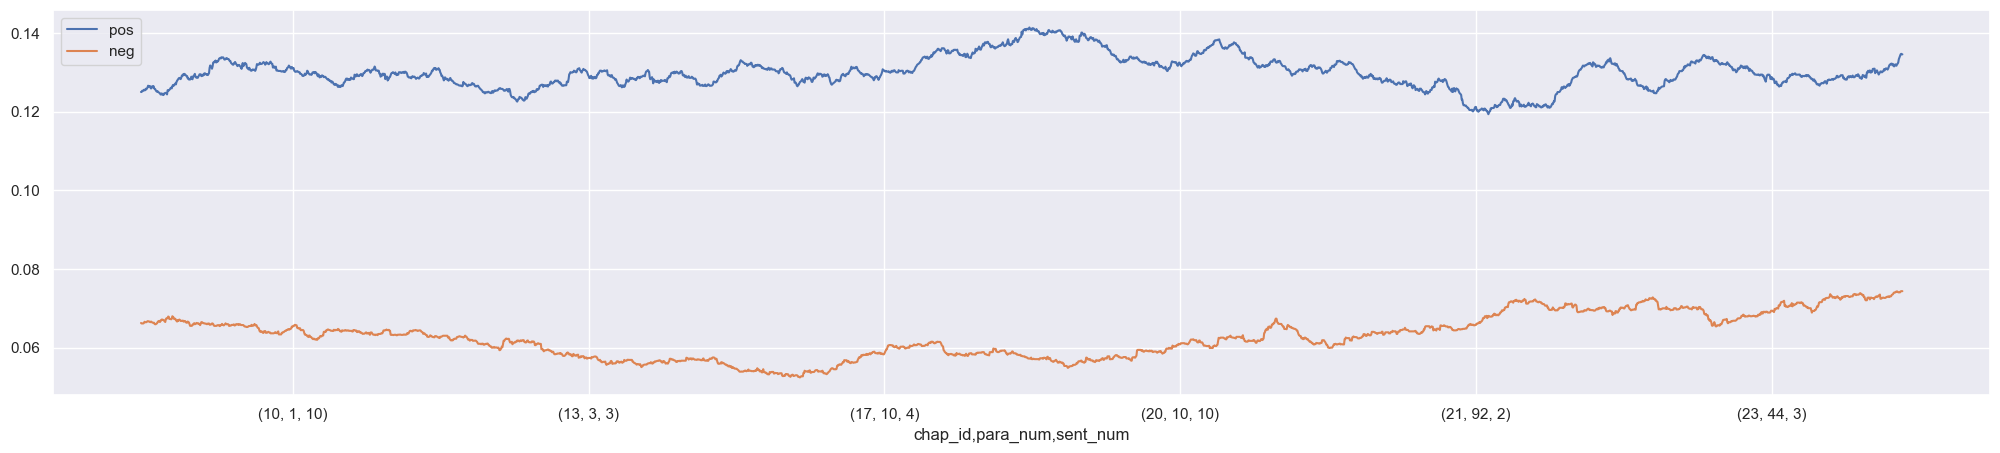

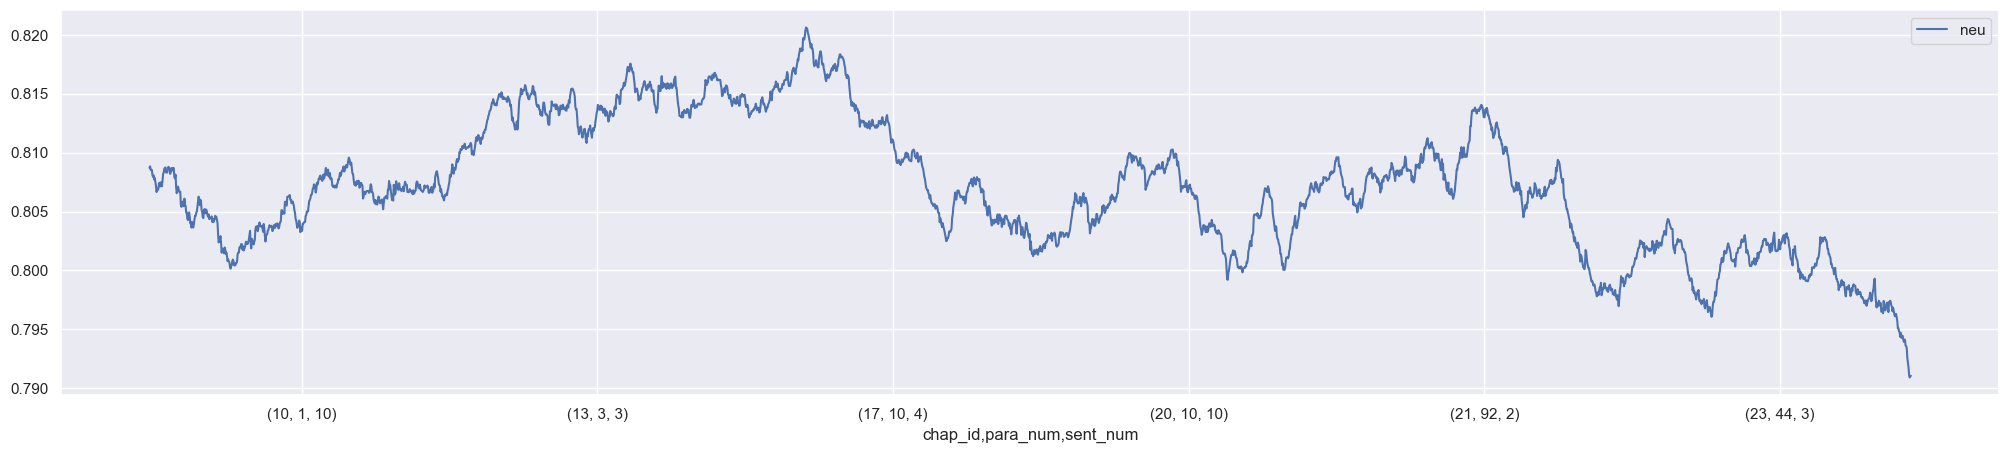

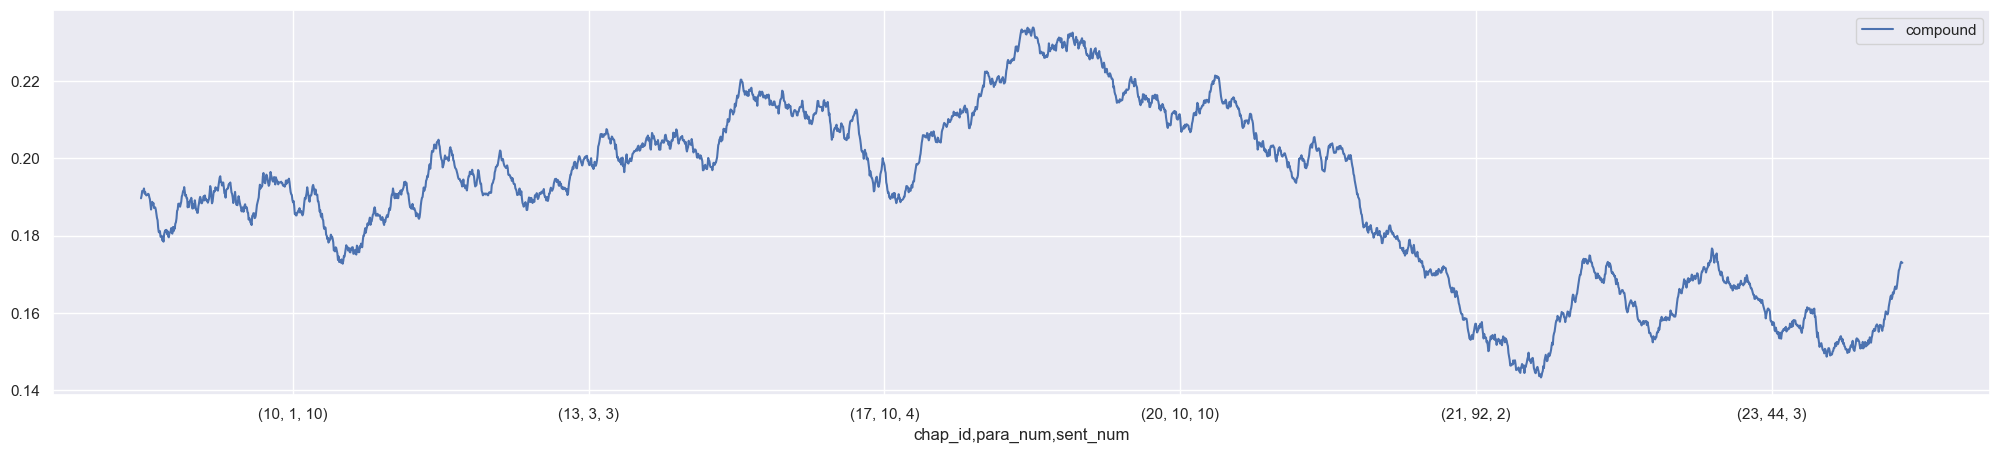

In [58]:
w = int(PERSUASION_vader.shape[0] / 5)
PERSUASION_vader[['pos','neg']].rolling(w).mean().plot(figsize=(25,5));
PERSUASION_vader[['neu']].rolling(w).mean().plot(figsize=(25,5));
PERSUASION_vader[['compound']].rolling(w).mean().plot(figsize=(25,5));

In [59]:
MOBYDICK_vader_cols = MOBYDICK_sents.sent_str.apply(analyser.polarity_scores).apply(lambda x: pd.Series(x))
MOBYDICK_vader = MOBYDICK_sents.join(MOBYDICK_vader_cols)

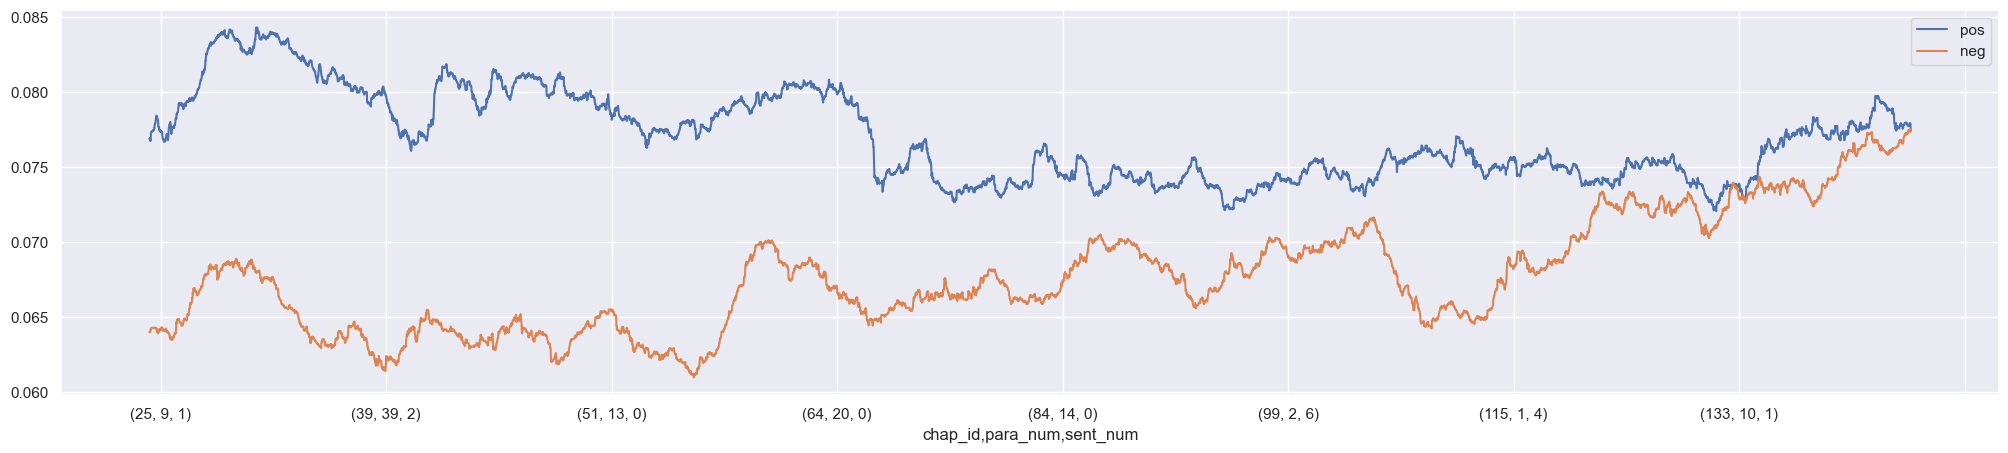

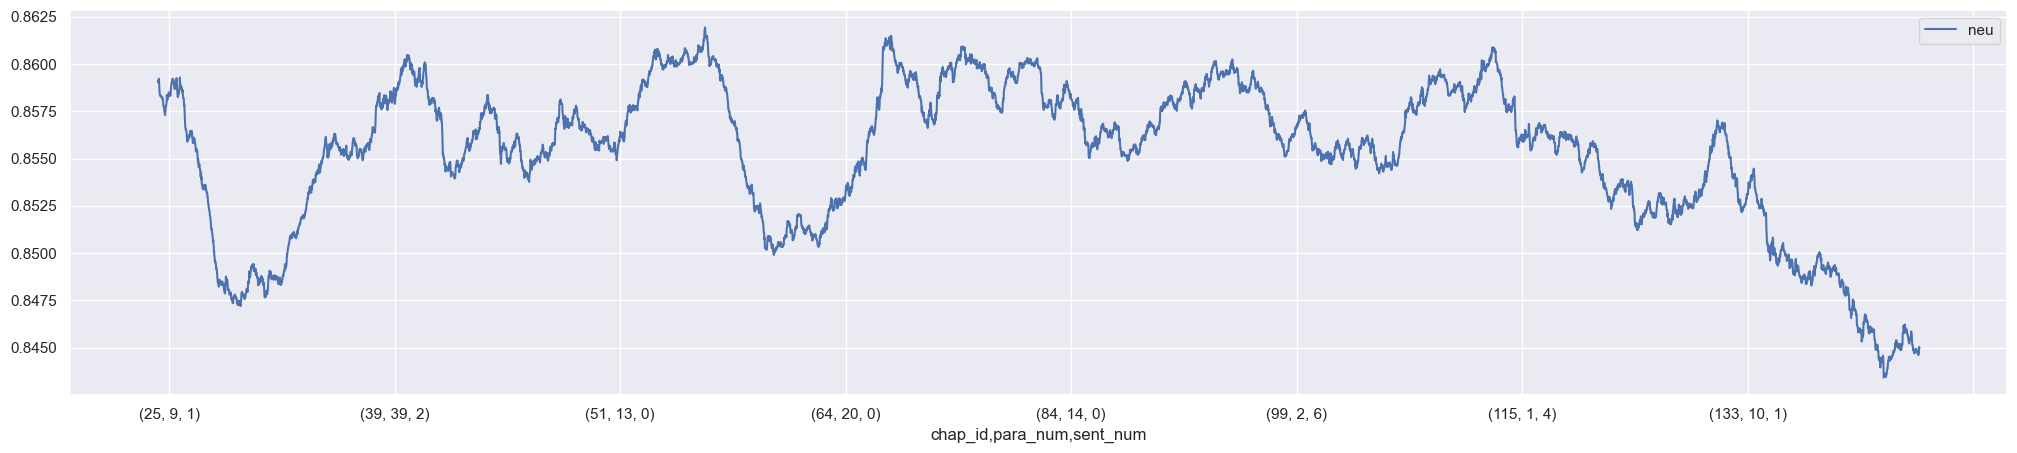

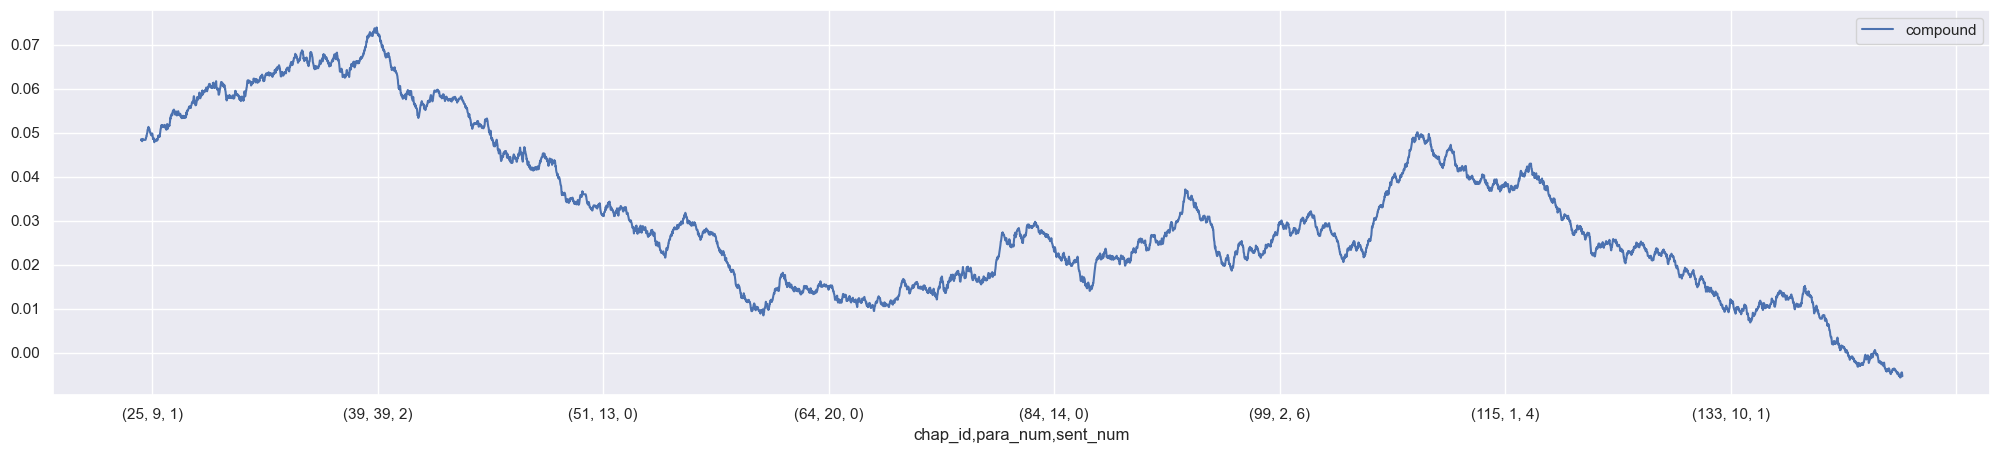

In [60]:
w = int(MOBYDICK_vader.shape[0] / 5)
MOBYDICK_vader[['pos','neg']].rolling(w).mean().plot(figsize=(25,5));
MOBYDICK_vader[['neu']].rolling(w).mean().plot(figsize=(25,5));
MOBYDICK_vader[['compound']].rolling(w).mean().plot(figsize=(25,5));

# Emo Space

In [61]:
import sys; sys.path.append("../lib/")
from hac2 import HAC

<Figure size 640x480 with 0 Axes>

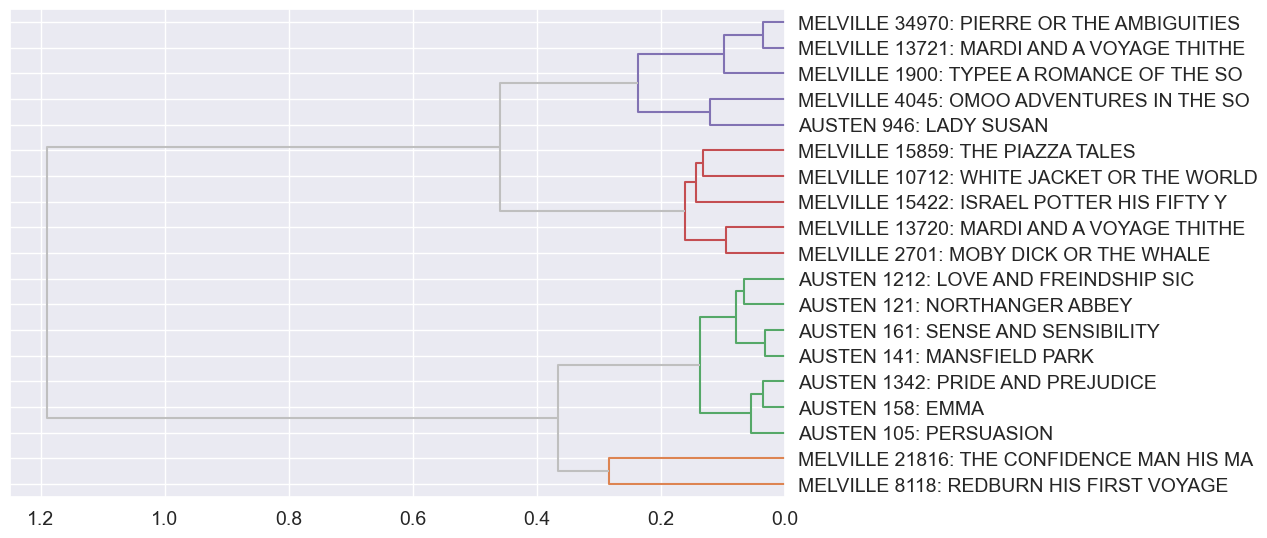

In [62]:
emo_tree = HAC(EMO_BOOKS)
emo_tree.color_thresh=.35
emo_tree.plot()

<Figure size 640x480 with 0 Axes>

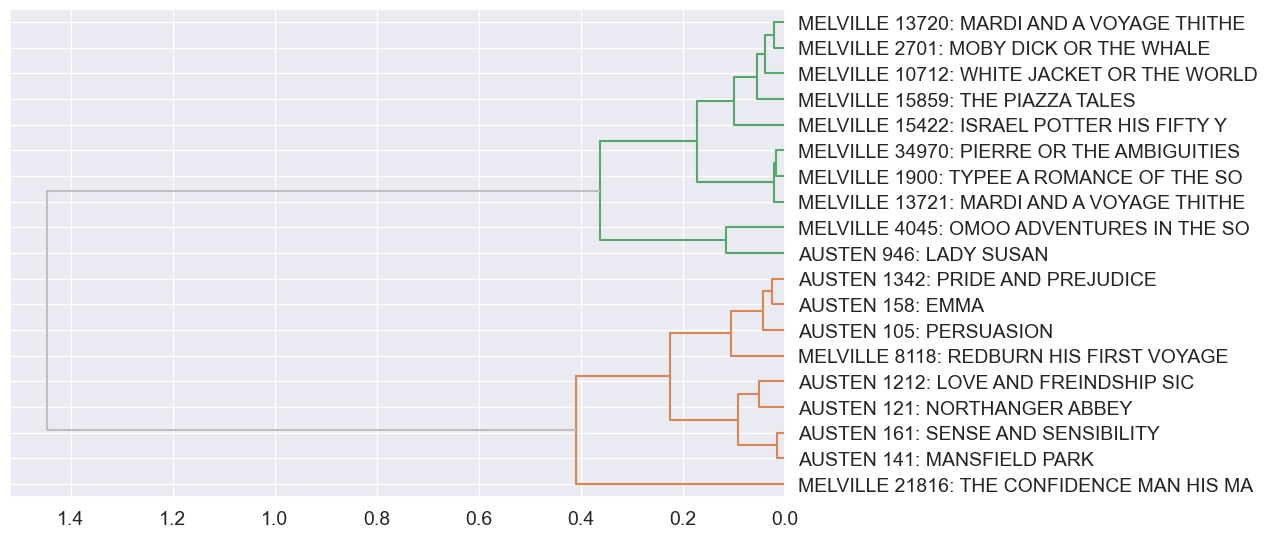

In [63]:
emo_tree = HAC(EMO_BOOKS.T.corr())
emo_tree.color_thresh=.5
emo_tree.plot()

# Save

In [64]:
B.to_csv(f"{output_dir}/{data_prefix}-SENTBOW.csv")